In [1]:

import warnings
import joblib
import time
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap.umap_ as umap
import umap.plot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr, f_oneway, chi2_contingency, chi2


# Suppress warnings
warnings.filterwarnings('ignore')


/Users/shounakchakraborty/opt/anaconda3/envs/recommend/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/shounakchakraborty/opt/anaconda3/envs/recommend/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Users/shounakchakraborty/opt/anaconda3/envs/recommend/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(m

In [2]:
# Loading datasets
movies_df = pd.read_csv("../data/filtered/movies.csv")
actors_df = pd.read_csv("../data/filtered/actors.csv")
directors_df = pd.read_csv("../data/filtered/directors.csv")
studios_df = pd.read_csv("../data/filtered/studios.csv")

In [3]:
# Merge actors, directors, studios data based on movie_id
merged_df = movies_df.copy()
merged_df["actors"] = merged_df["movie_id"].map(
    lambda x: tuple(actors_df[actors_df["movie_id"] == x]["actor_name"]) if x in actors_df["movie_id"].values else ()
)
merged_df["directors"] = merged_df["movie_id"].map(
    lambda x: tuple(directors_df[directors_df["movie_id"] == x]["director_name"]) if x in directors_df["movie_id"].values else ()
)
merged_df["studios"] = merged_df["movie_id"].map(
    lambda x: tuple(studios_df[studios_df["movie_id"] == x]["studio"]) if x in studios_df["movie_id"].values else ()
)

columns = [col for col in merged_df.columns if col != "rating"] + ["rating"]
merged_df = merged_df[columns]


In [4]:
merged_df['theatrical_release_age_rating'].isnull().sum()

2706

Assuming empty means "NR"

In [5]:
merged_df.loc[:, 'theatrical_release_age_rating'] = merged_df['theatrical_release_age_rating'].fillna('NR')
merged_df['theatrical_release_age_rating'].isnull().sum()

0

In [6]:
description_embeddings = np.load("../data/filtered/description_embeddings.npy")
tagline_embeddings = np.load("../data/filtered/tagline_embeddings.npy")
poster_embeddings = np.load("../data/filtered/poster_embeddings.npy")

Checking Embedding Statistics

In [7]:
print(f"Description embeddings shape: {description_embeddings.shape}")
print(f"Tagline embeddings shape: {tagline_embeddings.shape}")
print(f"Poster embeddings shape: {poster_embeddings.shape}")

def embedding_stats(embeddings, name):
    print(f"\n{name} Embeddings Statistics:")
    print(f"Mean: {np.mean(embeddings):.4f}")
    print(f"Std Dev: {np.std(embeddings):.4f}")
    print(f"Min: {np.min(embeddings):.4f}")
    print(f"Max: {np.max(embeddings):.4f}")
    
embedding_stats(description_embeddings, "Description")
embedding_stats(tagline_embeddings, "Tagline")
embedding_stats(poster_embeddings, "Poster")

Description embeddings shape: (10599, 768)
Tagline embeddings shape: (10599, 768)
Poster embeddings shape: (10599, 512)

Description Embeddings Statistics:
Mean: 0.0039
Std Dev: 0.7212
Min: -5.5678
Max: 3.8375

Tagline Embeddings Statistics:
Mean: 0.0057
Std Dev: 0.7970
Min: -6.2170
Max: 4.4667

Poster Embeddings Statistics:
Mean: -0.0079
Std Dev: 0.4432
Min: -9.5565
Max: 3.5996


The statistics show that all embeddings have means near zero and appropriate standard deviations, which is typical for properly normalized embeddings. The poster embeddings have a smaller standard deviation than the text embeddings, which could be due to the different models used.

# Visualise Embeddings

* UMAP 


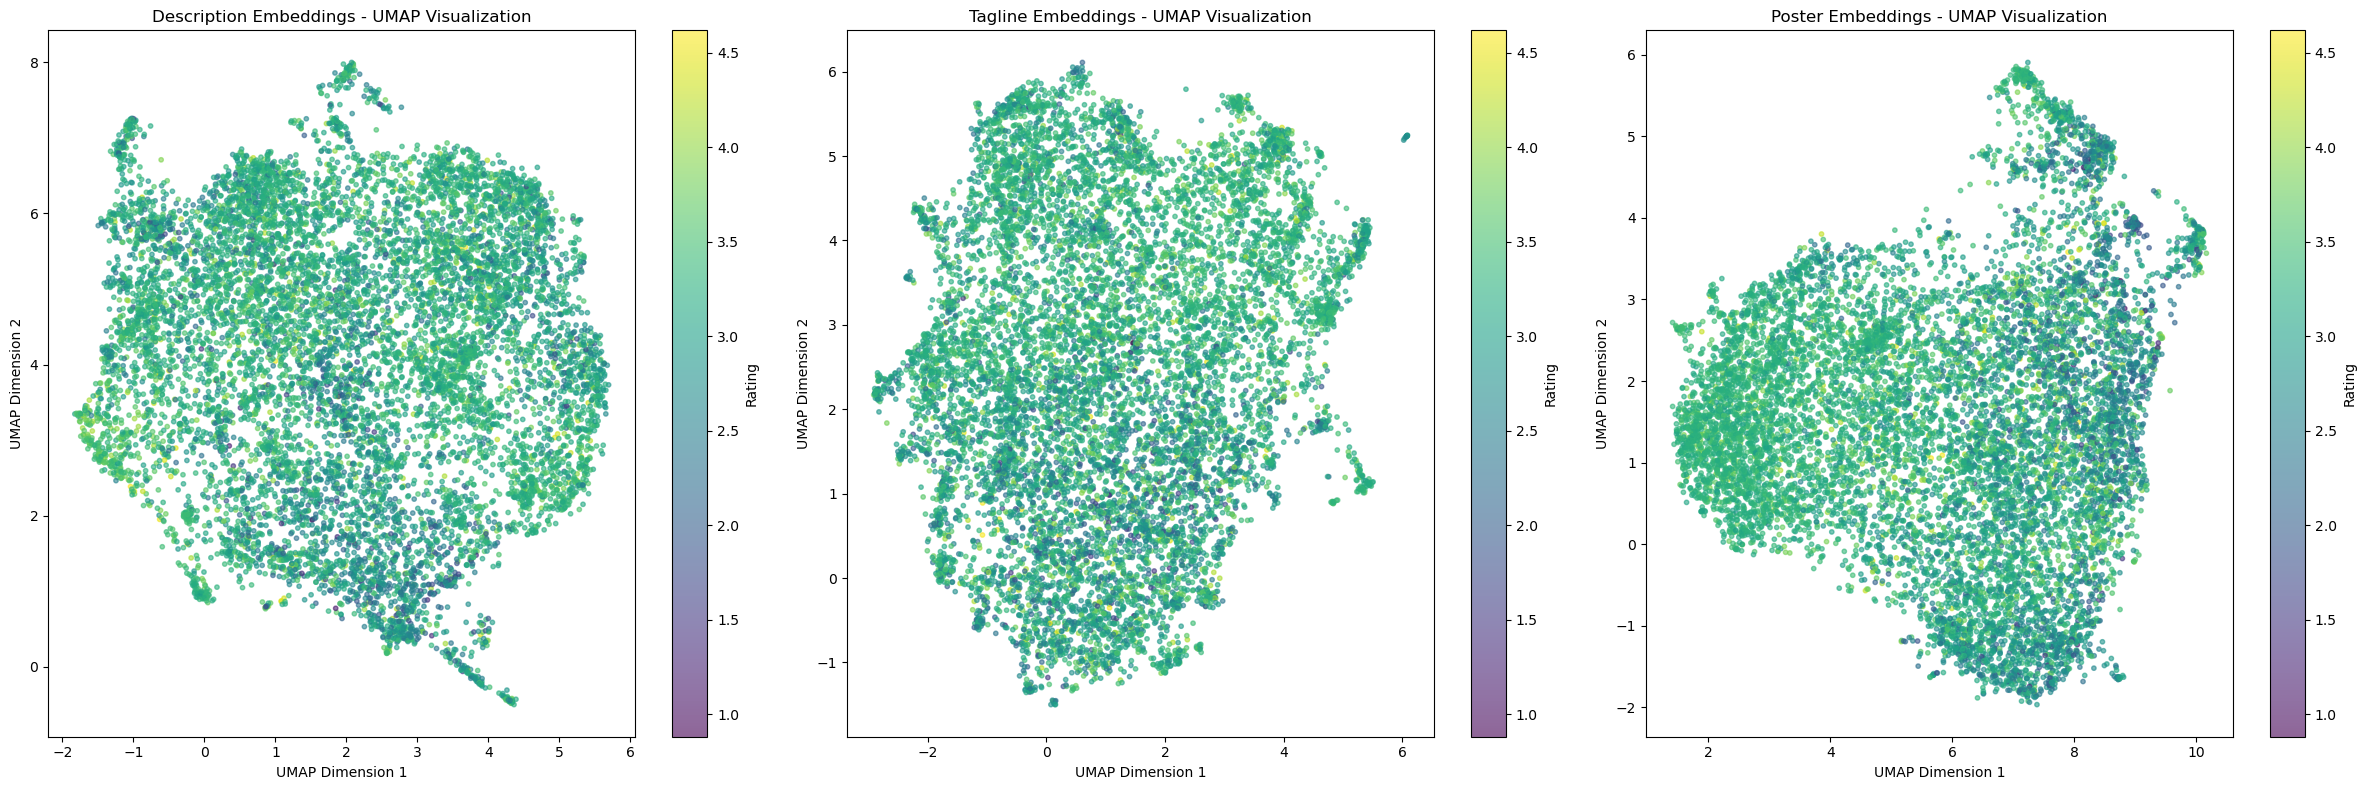

In [8]:


def visualize_embeddings_both(embeddings_list, titles, ratings, hover_data):
    # First, create static subplots
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Store all mappers for later interactive visualization
    mappers = []
    
    # Loop through each embedding and create a subplot
    for i, (embeddings, title) in enumerate(zip(embeddings_list, titles)):
        # Fit UMAP
        umap_model = umap.UMAP(n_components=2, random_state=42)
        mapper = umap_model.fit(embeddings)
        mappers.append(mapper)
        
        # Get the embedding
        embedding = mapper.embedding_
        
        # Create DataFrame for plotting
        viz_df = pd.DataFrame({
            'UMAP1': embedding[:, 0],
            'UMAP2': embedding[:, 1],
            'Rating': ratings
        })
        
        # Plot on the corresponding subplot
        scatter = axes[i].scatter(viz_df['UMAP1'], viz_df['UMAP2'],
                    c=viz_df['Rating'], cmap='viridis', alpha=0.6, s=10)
        axes[i].set_title(f'{title} - UMAP Visualization')
        axes[i].set_xlabel('UMAP Dimension 1')
        axes[i].set_ylabel('UMAP Dimension 2')
        
        # Add a colorbar to each subplot
        fig.colorbar(scatter, ax=axes[i], label='Rating')
    
    plt.tight_layout()
    plt.show()
    
    # Interactive plots 
    for mapper, title in zip(mappers, titles):
        p = umap.plot.interactive(mapper, labels=ratings, hover_data=hover_data)
        umap.plot.show(p)
    
    return mappers

# Create a list of embeddings and titles
embeddings_list = [description_embeddings, tagline_embeddings, poster_embeddings]
titles = ['Description Embeddings', 'Tagline Embeddings', 'Poster Embeddings']

# Create hover data
hover_data = pd.DataFrame({
    "Movie": merged_df["name"],
    "Year": merged_df["date"],
    "Age Rating": merged_df["theatrical_release_age_rating"],
    "Rating": merged_df["rating"]
})

# Visualize all embeddings with both static subplots and interactive plots
mappers = visualize_embeddings_both(embeddings_list, titles, merged_df["rating"], hover_data)


* All three plots (description, tagline, and poster) show the data points concentrated in a central cluster. This suggests that, in the reduced dimensional space created by UMAP, the movies are generally grouped together rather than forming distinct, well-separated clusters.

* Mix of age ratings throughout the cluster

* But we could see some patterns as per movie rating, green clusters have high rating, while red ones has low in the interactive plot

In [9]:
# Add embeddings to merged_with_embeddings
merged_with_embeddings = merged_df.copy()

# Ensure the number of embeddings matches the number of rows in merged_with_embeddings
assert len(description_embeddings) == len(merged_with_embeddings), "Mismatch in description embeddings length"
assert len(tagline_embeddings) == len(merged_with_embeddings), "Mismatch in tagline embeddings length"
assert len(poster_embeddings) == len(merged_with_embeddings), "Mismatch in poster embeddings length"

# Add embeddings as new columns
merged_with_embeddings['description_embeddings'] = list(description_embeddings)
merged_with_embeddings['tagline_embeddings'] = list(tagline_embeddings)
merged_with_embeddings['poster_embeddings'] = list(poster_embeddings)

columns = [col for col in merged_with_embeddings.columns if col != "rating"] + ["rating"]
merged_with_embeddings = merged_with_embeddings[columns]

# Display the updated DataFrame
merged_with_embeddings.head()

,movie_id,original_id,name,date,tagline,description,minute,theatrical_release_age_rating,actors,directors,studios,description_embeddings,tagline_embeddings,poster_embeddings,rating
0,0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,PG-13,"(Margot Robbie, Ryan Gosling, Ariana Greenblat...",(),"(Warner Bros. Pictures,)","[-0.60514545, 1.0947146, -4.216168, -0.6342678...","[0.76216596, -0.407509, -3.4711578, -0.8502319...","[-0.10932737, -0.5135564, -0.13299036, -0.2628...",3.86
1,1,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,R,"(Edward Norton, Brad Pitt, Helena Bonham Carte...","(David Fincher,)","(20th Century Fox,)","[-0.46973875, 0.96077377, -3.626686, -0.415978...","[0.43216592, 0.4715045, -5.0438867, -0.7668214...","[-0.14249939, -0.08135171, 0.095222935, -0.051...",4.27
2,2,1000006,Oppenheimer,2023,The world forever changes.,The story of J. Robert Oppenheimer's role in t...,181,R,"(Cillian Murphy, Emily Blunt, Matt Damon, Robe...","(Christopher Nolan,)","(Universal Pictures,)","[0.51440734, 0.81617844, -4.1623597, -0.465000...","[0.71240616, 0.10317001, -4.879042, -0.1469948...","[-0.2902962, 0.32712936, -0.19116507, 0.131835...",4.23
3,3,1000008,Joker,2019,Put on a happy face.,"During the 1980s, a failed stand-up comedian i...",122,R,"(Joaquin Phoenix, Robert De Niro, Zazie Beetz,...","(Todd Phillips,)","(Warner Bros. Pictures,)","[0.6422031, 0.6606501, -3.8914132, 0.19512044,...","[0.277219, 0.8402656, -4.8259287, 0.1698267, 0...","[0.09440977, -0.05906138, 0.19657609, -0.07425...",3.85
4,4,1000010,Pulp Fiction,1994,Just because you are a character doesn't mean ...,"A burger-loving hit man, his philosophical par...",154,R,"(John Travolta, Samuel L. Jackson, Uma Thurman...","(Quentin Tarantino,)","(Miramax,)","[0.18528554, 0.74321544, -4.1850834, 0.2480419...","[0.23912723, 0.040418647, -3.6882672, -0.74558...","[0.11112424, -0.29904175, -0.30449155, -0.4763...",4.26


In [10]:
# merged_with_embeddings.to_csv("../data/filtered/merged.csv", index=False)

In [11]:
# Calculate the average number of actors per movie, ignoring movies with 0 actors
average_actors = merged_with_embeddings[merged_with_embeddings["actors"].apply(len) > 0]["actors"].apply(len).mean()
average_directors = merged_with_embeddings[merged_with_embeddings["directors"].apply(len) > 0]["directors"].apply(len).mean()
average_studios = merged_with_embeddings[merged_with_embeddings["studios"].apply(len) > 0]["studios"].apply(len).mean()

print(f"Average number of actors per movie: {average_actors}")
print(f"Average number of directors per movie: {average_directors}")
print(f"Average number of studios per movie: {average_studios}")

Average number of actors per movie: 15.224856111598868
Average number of directors per movie: 1.0237416904083572
Average number of studios per movie: 1.0798188508349844


In [12]:
# Keep only the first n actors from the actors tuple
merged_df_top_n = merged_with_embeddings.copy()

n_actors = 5
merged_df_top_n['actors_top_n'] = merged_df_top_n['actors'].apply(lambda x: x[:min(n_actors, len(x))])
columns = [col for col in merged_df_top_n.columns if col != "rating"] + ["rating"]
merged_df_top_n = merged_df_top_n[columns]
# merged_df_top_n.to_csv("../data/filtered/merged_top_n.csv", index=False)
# Display the new DataFrame
# print(merged_df_top_n.head())
average_actors_top_n = merged_df_top_n[merged_df_top_n["actors_top_n"].apply(len) > 0]["actors_top_n"].apply(len).mean()

print(f"Average number of actors per movie: {average_actors_top_n}")


Average number of actors per movie: 4.681494488342601


In [13]:
merged_df_top_n.shape

(10599, 16)

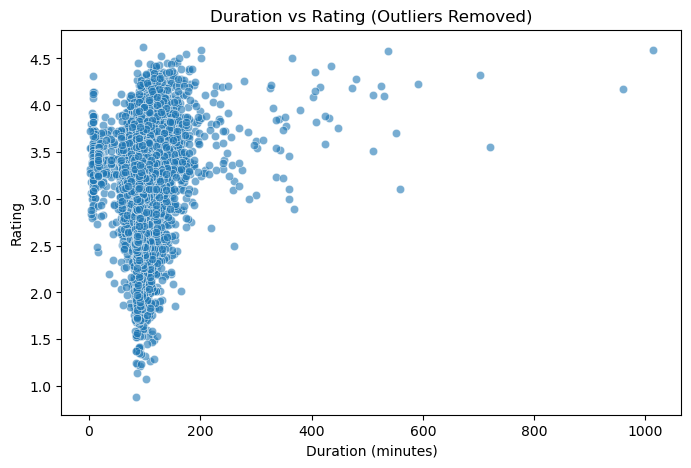

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_df_top_n, x='minute', y='rating', alpha=0.6)
plt.title("Duration vs Rating (Outliers Removed)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.show()

# Filtering

* Introducing IQR to get rid of ouliers

In [15]:
def edq_iqr(dataframe, feature1, feature2):
    # IQR for 'minute' and 'rating'
    Q1_minute = dataframe[f'{feature1}'].quantile(0.20)
    Q3_minute = dataframe[f'{feature1}'].quantile(0.80)
    IQR_minute = Q3_minute - Q1_minute

    Q1_rating = dataframe[f'{feature2}'].quantile(0.20)
    Q3_rating = dataframe[f'{feature2}'].quantile(0.80)
    IQR_rating = Q3_rating - Q1_rating

    # lower and upper bounds for outliers
    lower_bound_minute = Q1_minute - 1.5 * IQR_minute
    upper_bound_minute = Q3_minute + 1.5 * IQR_minute

    lower_bound_rating = Q1_rating - 1.5 * IQR_rating
    upper_bound_rating = Q3_rating + 1.5 * IQR_rating

    # Filter the DataFrame to remove outliers
    filtered_df = dataframe[
        (dataframe[f'{feature1}'] >= lower_bound_minute) & 
        (dataframe[f'{feature1}'] <= upper_bound_minute) &
        (dataframe[f'{feature2}'] >= lower_bound_rating) & 
        (dataframe[f'{feature2}'] <= upper_bound_rating)
    ]
    print(f"Number of outliers removed: {dataframe.shape[0] - filtered_df.shape[0]}")
    # Plot the filtered data
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=filtered_df, x=feature1, y=feature2, alpha=0.6)
    plt.title("Duration vs Rating (Outliers Removed)")
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Rating")
    plt.show()

    return filtered_df

Number of outliers removed: 567


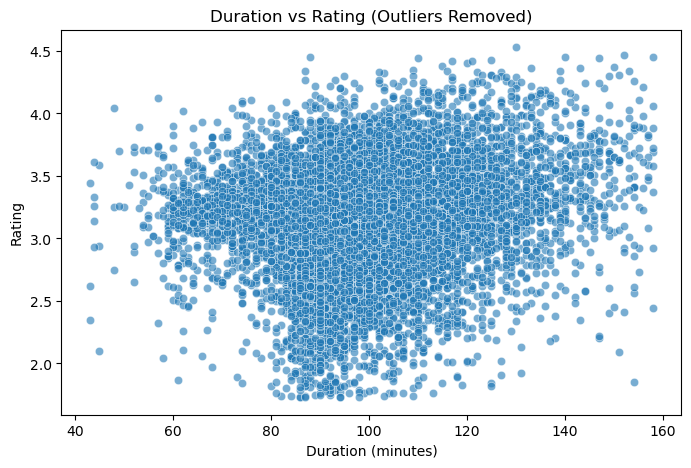

In [16]:
filtered_duration = edq_iqr(merged_df_top_n, 'minute', 'rating')

### Testing co-relation between Rating and Duration

In [17]:

# Pearson correlation between duration and rating
pearson_corr, p_value = pearsonr(filtered_duration['minute'], filtered_duration['rating'])
print(f"Pearson Correlation: corr={pearson_corr}, p-value={p_value}")

# Spearman correlation between duration and rating
spearman_corr, p_value = spearmanr(filtered_duration['minute'], filtered_duration['rating'])
print(f"Spearman Correlation: corr={spearman_corr}, p-value={p_value}")


Pearson Correlation: corr=0.162076793974401, p-value=5.149771514117192e-60
Spearman Correlation: corr=0.15089190748086878, p-value=3.61675040512687e-52


* Both tests show a very weak positive correlation between movie duration (minute) and rating. The p-values are extremely low, indicating statistical significance, but the correlation coefficients are close to zero.

In [18]:
filtered_duration.shape

(10032, 16)

### Checking more empty values

In [19]:
# Checking rows with empty tuples in 'actors', 'directors', and 'studios' columns
empty_actors = filtered_duration[filtered_duration['actors'].apply(lambda x: len(x) == 0)]
empty_directors = filtered_duration[filtered_duration['directors'].apply(lambda x: len(x) == 0)]
empty_studios = filtered_duration[filtered_duration['studios'].apply(lambda x: len(x) == 0)]

# Print the results
print(f"Number of rows with empty 'actors': {len(empty_actors)}")
print(f"Number of rows with empty 'directors': {len(empty_directors)}")
print(f"Number of rows with empty 'studios': {len(empty_studios)}")


Number of rows with empty 'actors': 285
Number of rows with empty 'directors': 5061
Number of rows with empty 'studios': 0


### Helper Plot funtions

In [20]:
def plot_rating_distribution(dataframe):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot the distribution of ratings
    sns.histplot(dataframe["rating"], ax=axes[0, 0])
    axes[0, 0].set_title("Distribution of Movie Ratings")
    axes[0, 0].set_xlabel("Movie Rating")
    axes[0, 0].set_ylabel("Count")

    # Rating by content rating
    sns.boxplot(x='theatrical_release_age_rating', y='rating', data=dataframe, ax=axes[0, 1])
    axes[0, 1].set_title('Movie Ratings by Content Rating')
    axes[0, 1].set_xlabel('Content Rating')
    axes[0, 1].set_ylabel('Movie Rating')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # Count of movies by content rating
    content_rating_counts = dataframe['theatrical_release_age_rating'].value_counts()
    sns.barplot(x=content_rating_counts.index, y=content_rating_counts.values, ax=axes[1, 0])
    axes[1, 0].set_title('Number of Movies by Content Rating')
    axes[1, 0].set_xlabel('Content Rating')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Average rating by content rating
    avg_rating_by_content = dataframe.groupby('theatrical_release_age_rating')['rating'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_rating_by_content.index, y=avg_rating_by_content.values, ax=axes[1, 1])
    axes[1, 1].set_title('Average Rating by Content Rating')
    axes[1, 1].set_xlabel('Content Rating')
    axes[1, 1].set_ylabel('Average Movie Rating')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Statistical summary by content rating
    content_rating_stats = dataframe.groupby('theatrical_release_age_rating')['rating'].agg(['count', 'mean', 'std', 'min', 'max'])
    print("Rating statistics by content rating:")
    print(content_rating_stats.sort_values('mean', ascending=False))

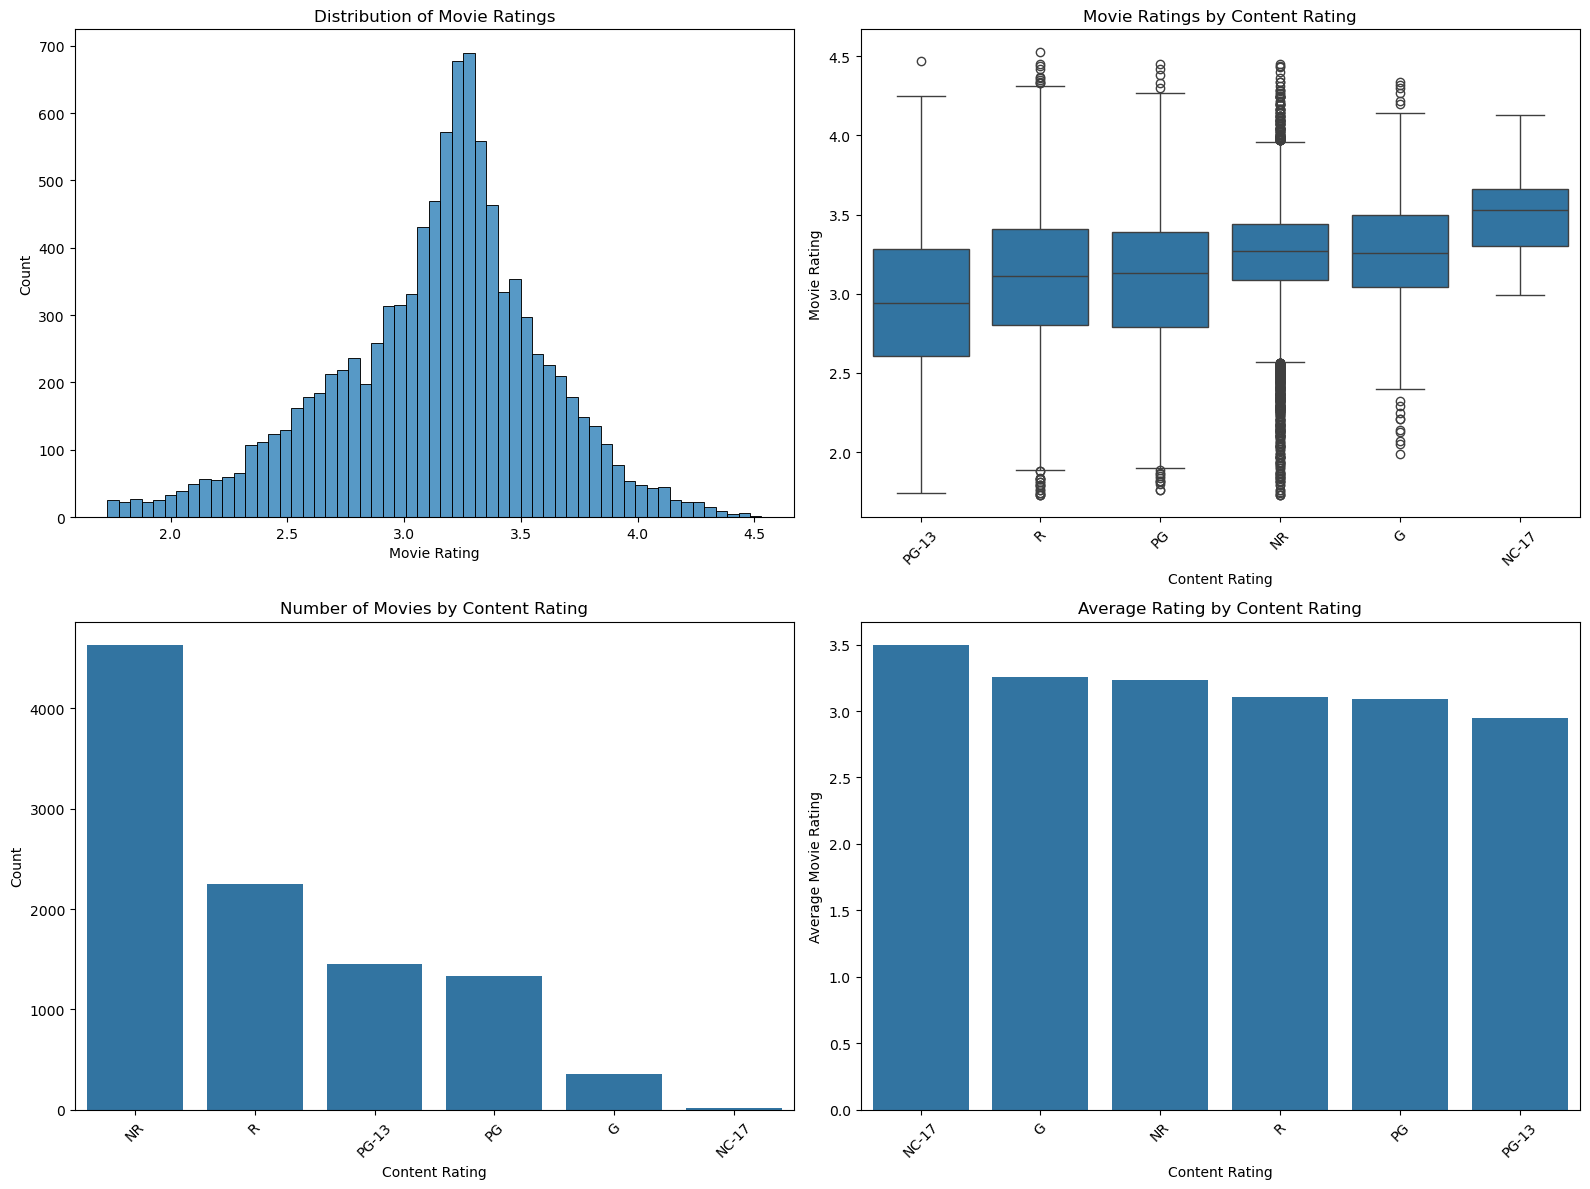

Rating statistics by content rating:
                               count      mean       std   min   max
theatrical_release_age_rating                                       
NC-17                             13  3.496923  0.308906  2.99  4.13
G                                351  3.255214  0.410202  1.99  4.34
NR                              4632  3.232746  0.392576  1.73  4.45
R                               2250  3.106262  0.478555  1.73  4.53
PG                              1330  3.093925  0.471750  1.76  4.45
PG-13                           1456  2.945810  0.478037  1.74  4.47


In [21]:
plot_rating_distribution(filtered_duration)

* NC-17 movies have the highest median rating (approximately 3.5-3.6)
* G and R rated movies show similar median ratings (around 3.3)
* PG-13 shows the lowest median rating (around 3.0)
* All categories have outliers with high ratings near 4.5

### ANOVA test to test hypothesis

In [22]:

groups = [filtered_duration[filtered_duration['theatrical_release_age_rating'] == rating]['rating'] 
          for rating in filtered_duration['theatrical_release_age_rating'].unique()]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA: F-stat={f_stat}, p-value={p_value}")

ANOVA: F-stat=111.03016605226111, p-value=1.5084894369355936e-114


* A high F-statistic (like 111.03) indicating that the differences between group means are significant compared to the variability within groups and low p-value  means statistically significant difference in movie ratings across the different theatrical_release_age_rating groups. 
* Test suggests that movie ratings differ significantly based on the theatrical release age rating



### Custom encoding based on decreasing mean ratings

In [23]:
rating_map = {
    'NC-17': 3.50,  # Highest mean rating
    'G': 3.26,
    'NR': 3.23,
    'R': 3.11,
    'PG': 3.09,
    'PG-13': 2.95   # Lowest mean rating
}
filtered_encoded = filtered_duration.copy()
filtered_encoded.loc[:, 'theatrical_release_age_rating_encoded'] = filtered_encoded['theatrical_release_age_rating'].map(rating_map)

columns = [col for col in filtered_encoded.columns if col != "rating"] + ["rating"]
filtered_encoded = filtered_encoded[columns]


In [24]:
filtered_encoded.columns

Index(['movie_id', 'original_id', 'name', 'date', 'tagline', 'description',
       'minute', 'theatrical_release_age_rating', 'actors', 'directors',
       'studios', 'description_embeddings', 'tagline_embeddings',
       'poster_embeddings', 'actors_top_n',
       'theatrical_release_age_rating_encoded', 'rating'],
      dtype='object')

### Analyze Top n Directors, Movies


In [25]:
def analyze_movie_frequencies(dataframe):
    # Top 10 Directors with the Most Movies Directed
    directors_flattened = [director for directors in dataframe['directors'] for director in directors]
    top_10_directors = pd.Series(directors_flattened).value_counts().head(10)
    print("Top 10 Directors with the Most Movies Directed:")
    print(top_10_directors)
    
    # Top 10 Actors with the Most Movie Appearances
    actors_flattened = [actor for actors in dataframe['actors_top_n'] for actor in actors]
    top_10_actors = pd.Series(actors_flattened).value_counts().head(10)
    print("\nTop 10 Actors with the Most Movie Appearances:")
    print(top_10_actors)

def analyze_movie_ratings(dataframe):
    # Top 10 Directors with the Highest Average Ratings
    director_ratings = dataframe.explode('directors').groupby('directors')['rating'].mean()
    top_10_highest_rated_directors = director_ratings.sort_values(ascending=False).head(10)
    print("Top 10 Directors with the Highest Average Ratings:")
    print(top_10_highest_rated_directors)
    
    # Top 10 Actors with the Highest Average Ratings
    actor_ratings = dataframe.explode('actors_top_n').groupby('actors_top_n')['rating'].mean()
    top_10_highest_rated_actors = actor_ratings.sort_values(ascending=False).head(10)
    print("\nTop 10 Actors with the Highest Average Ratings:")
    print(top_10_highest_rated_actors)
    
    # Top 10 Studios with the Highest Average Ratings
    studio_ratings = dataframe.explode('studios').groupby('studios')['rating'].mean()
    top_10_highest_rated_studios = studio_ratings.sort_values(ascending=False).head(10)
    print("\nTop 10 Studios with the Highest Average Ratings:")
    print(top_10_highest_rated_studios)
    
    # Create a subplot for the two visualizations
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Top 10 Years with Highest Average Ratings
    year_ratings = dataframe.groupby('date')['rating'].mean()
    sns.lineplot(data=year_ratings, marker='o', ax=axes[0])
    axes[0].set_title("Average Movie Ratings by Year")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Average Rating")
    axes[0].grid(True)

    # Average Number of Movies vs Year
    year_movie_counts = dataframe['date'].value_counts().sort_index()
    sns.lineplot(x=year_movie_counts.index, y=year_movie_counts.values, marker='o', ax=axes[1])
    axes[1].set_title("Average Number of Movies by Year")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Number of Movies")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def run_movie_eda(dataframe):
    """Run all Exploratory Data Analysis functions."""
    analyze_movie_frequencies(dataframe)
    print("\n" + "="*50 + "\n")
    analyze_movie_ratings(dataframe)


Top 10 Directors with the Most Movies Directed:
Michael Curtiz       66
John Ford            58
Raoul Walsh          44
George Cukor         37
Mervyn LeRoy         35
Vincente Minnelli    35
Clint Eastwood       34
Henry Hathaway       33
Howard Hawks         32
Richard Thorpe       31
Name: count, dtype: int64

Top 10 Actors with the Most Movie Appearances:
John Wayne          72
Barbara Stanwyck    69
Bette Davis         65
James Stewart       62
Humphrey Bogart     61
Cary Grant          55
Joan Crawford       53
Clark Gable         50
Spencer Tracy       50
Robert Mitchum      50
Name: count, dtype: int64


Top 10 Directors with the Highest Average Ratings:
directors
David Lynch             4.195000
Charlie Chaplin         4.065714
Stanley Kubrick         4.028889
Christopher Nolan       3.978333
Quentin Tarantino       3.978333
Paul Thomas Anderson    3.972000
David Fincher           3.895000
Orson Welles            3.885714
Hal Ashby               3.806667
Billy Wilder          

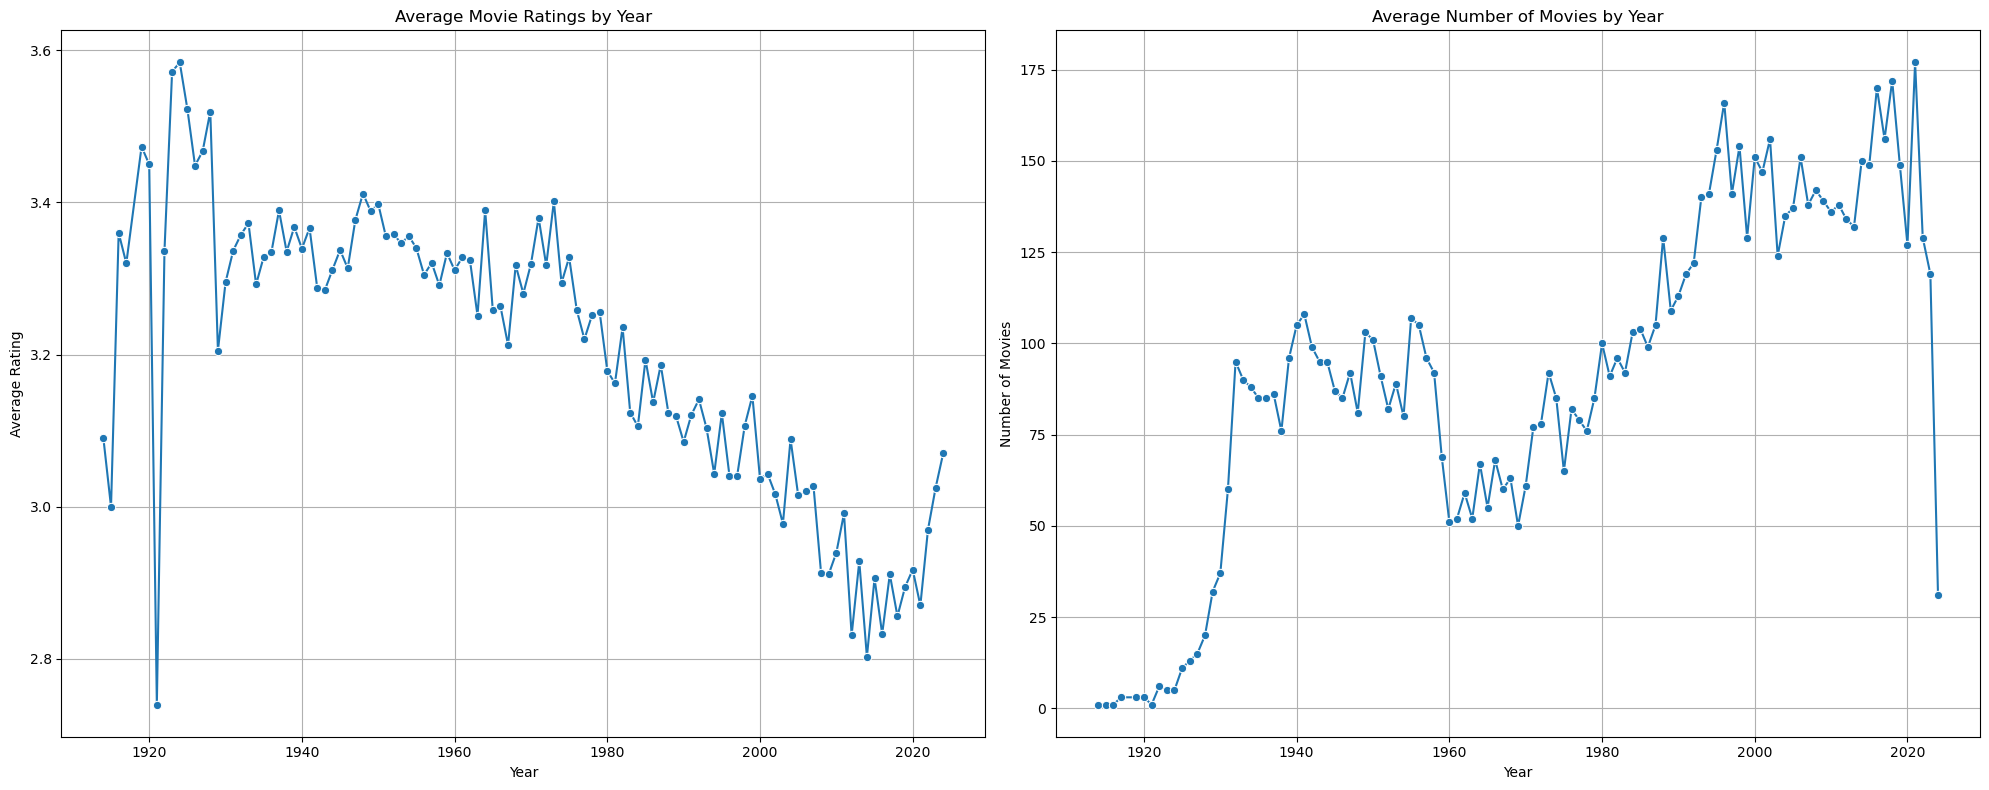

In [26]:
run_movie_eda(filtered_encoded)

### Plotting Weighted Distribution

In [27]:
def plot_weighted_rating_distribution(dataframe):
    # Group by year and calculate the total number of movies and weighted average rating
    year_stats = dataframe.groupby('date').agg(
        total_movies=('rating', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()
    
    # Normalize the total number of movies for scaling
    year_stats['normalized_movies'] = year_stats['total_movies'] / year_stats['total_movies'].max()
    year_stats['normalized_rating'] = year_stats['avg_rating'] / year_stats['avg_rating'].max()

    # Create a weighted rating by multiplying the average rating with normalized movie count
    year_stats['weighted_avg_rating'] = 0.5* year_stats['normalized_rating'] + 0.5* year_stats['normalized_movies']
    year_stats['weighted_avg_rating_scaled'] = (0.5* year_stats['normalized_rating'] + 0.5* year_stats['normalized_movies']) * 5

    filtered_scaled_rating = filtered_duration.merge(year_stats[['date', 'weighted_avg_rating_scaled']], on='date', how='left')

    # Plot the weighted rating distribution
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=year_stats, x='date', y='normalized_movies', marker='o', label='Total Movies (Normalized)')
    sns.lineplot(data=year_stats, x='date', y='normalized_rating', marker='o', label='Average Rating (Normalized)')
    sns.lineplot(data=year_stats, x='date', y='weighted_avg_rating', marker='o', label='Weighted Average Rating', linestyle='--')
    sns.lineplot(data=year_stats, x='date', y='weighted_avg_rating_scaled', marker='o', label='Weighted Average Rating (Scaled)', linestyle='--')

    plt.title("Weighted Rating Distribution Over Years")
    plt.xlabel("Year")
    plt.ylabel("Rating")
    plt.legend()
    plt.grid(True)
    plt.show()

    return filtered_scaled_rating



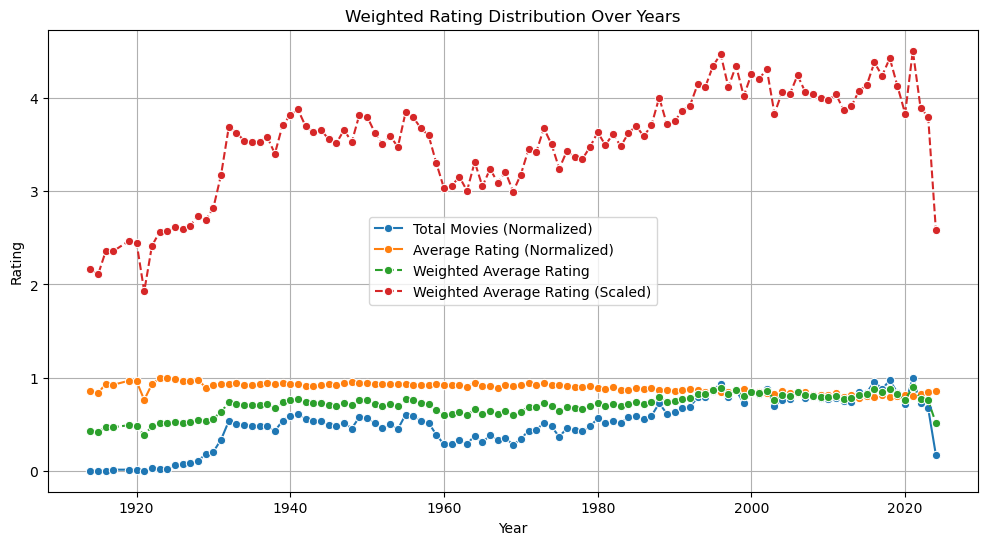

In [28]:
filtered_scaled_rating = plot_weighted_rating_distribution(filtered_encoded)

* ! Need to See if something could be done with this data.

### Checking if there is an association between age rating and actors or directors or studios

In [29]:

def test_category_age_relationship(df, category):
    # Explode the category tuple to get one row per category
    exploded_df = df.explode(category)
    
    categories = exploded_df[category].value_counts().index.tolist()
    
    # Filter for only top category
    filtered_df_exploded = exploded_df[exploded_df[category].isin(categories)]
    
    # Create contingency table
    contingency = pd.crosstab(filtered_df_exploded[category], filtered_df_exploded['theatrical_release_age_rating'])
    
    # Run chi-square test
    chi2_stat, p_value, dof, _ = chi2_contingency(contingency)
    
    print(f"Chi-square statistic: {chi2_stat:.2f}")
    print(f"p-value: {p_value:.10f}")
    print(f"Degrees of freedom: {dof}")

    # Calculate Cramer's V
    n = contingency.sum().sum()
    phi2 = chi2_stat / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    
    print(f"\nCramer's V (effect size): {cramers_v:.4f}")
    if cramers_v < 0.1:
        print("Very weak association")
    elif cramers_v < 0.3:
        print("Weak association")
    elif cramers_v < 0.5:
        print("Moderate association")
    else:
        print("Strong association")


In [30]:
for category in ['actors_top_n', 'directors', 'studios']:
    print(f"\nTesting relationship between {category} and age rating:")
    test_category_age_relationship(filtered_encoded, category)



Testing relationship between actors_top_n and age rating:
Chi-square statistic: 79834.61
p-value: 0.0000000000
Degrees of freedom: 40780

Cramer's V (effect size): 0.4117
Moderate association

Testing relationship between directors and age rating:
Chi-square statistic: 9400.26
p-value: 0.0000000000
Degrees of freedom: 2220

Cramer's V (effect size): 0.5314
Strong association

Testing relationship between studios and age rating:
Chi-square statistic: 5602.98
p-value: 0.0000000000
Degrees of freedom: 695

Cramer's V (effect size): 0.3013
Moderate association


In [31]:
filtered_encoded.columns

Index(['movie_id', 'original_id', 'name', 'date', 'tagline', 'description',
       'minute', 'theatrical_release_age_rating', 'actors', 'directors',
       'studios', 'description_embeddings', 'tagline_embeddings',
       'poster_embeddings', 'actors_top_n',
       'theatrical_release_age_rating_encoded', 'rating'],
      dtype='object')

In [32]:
# Drop the specified columns from the DataFrame
filtered_dropped = filtered_encoded.drop(columns=['original_id', 'actors', 'tagline', 'description','theatrical_release_age_rating'])

# Display the updated columns
filtered_dropped.columns

Index(['movie_id', 'name', 'date', 'minute', 'directors', 'studios',
       'description_embeddings', 'tagline_embeddings', 'poster_embeddings',
       'actors_top_n', 'theatrical_release_age_rating_encoded', 'rating'],
      dtype='object')

* Used Chat-Gpt to generate the below code
* Target Label Encoding
* Idea was to use the mean of the other existing categories as the encoded value if empty, and avoid data leakage, so KFOLD

In [33]:
def kfold_target_encoder(df, category_cols, target_col='rating', n_folds=5, min_samples=10, smoothing=True, smoothing_factor=10):
    """
    Performs k-fold target encoding on multiple categorical columns with fallback to other categories when needed.
    """
    result_df = df.copy()
    all_encodings = {}
    global_mean = df[target_col].mean()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Compute target encoding for each categorical column
    for col in category_cols:
        temp_df = df.explode(col)
        entity_counts = temp_df[col].value_counts()
        entity_encoded = {}
        
        for train_idx, _ in kf.split(temp_df):
            train_df = temp_df.iloc[train_idx]
            means = train_df.groupby(col)[target_col].agg(['mean', 'count'])
            
            for entity, (mean, count) in means.iterrows():
                if count >= min_samples:
                    smoothed = (count * mean + smoothing_factor * global_mean) / (count + smoothing_factor) if smoothing else mean
                    entity_encoded[entity] = smoothed
        
        all_encodings[col] = entity_encoded
    
    # Apply encodings with fallback strategy
    def encode(row, col):
        values = row[col]
        encodings = [all_encodings[col].get(val) for val in values if val in all_encodings[col]]
        
        if encodings:
            return np.mean(encodings)
        
        # Fallback: Use mean encoding from other categories
        fallback_encodings = [
            np.mean([all_encodings[other_col].get(val) for val in row[other_col] if val in all_encodings[other_col]])
            for other_col in category_cols if other_col != col and row[other_col]
        ]
        
        return np.mean(fallback_encodings) if fallback_encodings else global_mean
    
    for col in category_cols:
        result_df[f'{col}_encoded'] = result_df.apply(lambda row: encode(row, col), axis=1)
    
    return result_df, all_encodings


# Apply to all categories at once
category_cols = ['directors', 'studios', 'actors_top_n']
filtered_dropped_encoded, all_category_encodings = kfold_target_encoder(
    filtered_dropped, category_cols, target_col='rating'
)


In [34]:
final_data = filtered_dropped_encoded.drop(columns=['directors', 'studios', 'actors_top_n', 'name'])
columns = [col for col in final_data.columns if col != "rating"] + ["rating"]
final_data = final_data[columns]
final_data.columns


Index(['movie_id', 'date', 'minute', 'description_embeddings',
       'tagline_embeddings', 'poster_embeddings',
       'theatrical_release_age_rating_encoded', 'directors_encoded',
       'studios_encoded', 'actors_top_n_encoded', 'rating'],
      dtype='object')

In [35]:
final_data.head(5)

,movie_id,date,minute,description_embeddings,tagline_embeddings,poster_embeddings,theatrical_release_age_rating_encoded,directors_encoded,studios_encoded,actors_top_n_encoded,rating
0,0,2023,114,"[-0.60514545, 1.0947146, -4.216168, -0.6342678...","[0.76216596, -0.407509, -3.4711578, -0.8502319...","[-0.10932737, -0.5135564, -0.13299036, -0.2628...",2.95,3.194495,3.190396,3.198594,3.86
1,1,1999,139,"[-0.46973875, 0.96077377, -3.626686, -0.415978...","[0.43216592, 0.4715045, -5.0438867, -0.7668214...","[-0.14249939, -0.08135171, 0.095222935, -0.051...",3.11,3.256644,3.193534,3.319754,4.27
3,3,2019,122,"[0.6422031, 0.6606501, -3.8914132, 0.19512044,...","[0.277219, 0.8402656, -4.8259287, 0.1698267, 0...","[0.09440977, -0.05906138, 0.19657609, -0.07425...",3.11,3.229086,3.190396,3.267776,3.85
4,4,1994,154,"[0.18528554, 0.74321544, -4.1850834, 0.2480419...","[0.23912723, 0.040418647, -3.6882672, -0.74558...","[0.11112424, -0.29904175, -0.30449155, -0.4763...",3.11,3.103713,3.153410,3.054016,4.26
5,5,2018,117,"[0.12091819, 0.76484895, -3.3724568, -0.146586...","[-0.911488, 0.67211306, -5.6958933, 0.36262718...","[-0.08147468, 0.1736213, 0.06273636, -0.203605...",3.09,3.196741,3.170254,3.223229,4.42


In [36]:
# Make sure the number of embeddings matches your dataset
print(f"Number of movies in filtered_encoded: {final_data.shape}")

Number of movies in filtered_encoded: (10032, 11)


In [37]:
# final_data.to_csv("../data/filtered/final_data.csv", index=False)

### Prepare for training

In [38]:
df = final_data.copy()

### Function to evaluate model performance


In [39]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} Performance Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    return {
        'model': model_name,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

### Extract Embeddings from dataframe

In [40]:
def extract_embeddings(df, column_name):
    embeddings_list = []
    for emb in df[column_name]:
        if isinstance(emb, np.ndarray):
            embeddings_list.append(emb)
    return np.array(embeddings_list)


### Set to True to combine tabular features with PCA components from embeddings 

In [41]:
combined = True 

In [42]:
# Set up directory for saving models
if combined:
    model_dir = "combined_models"
else:
    model_dir = "separate_models"
os.makedirs(model_dir, exist_ok=True)

### Starting movie rating prediction pipeline

In [43]:

# Extract embeddings with progress bar
print("Extracting embeddings from DataFrame")
embeddings = {}
embedding_columns = ['description_embeddings', 'tagline_embeddings', 'poster_embeddings']

for column in tqdm(embedding_columns, desc="Processing embedding columns"):
    embeddings[column.split('_')[0]] = extract_embeddings(df, column)

Extracting embeddings from DataFrame


Processing embedding columns: 100%|██████████| 3/3 [00:00<00:00, 140.41it/s]


### Apply PCA to each type of embedding

In [44]:
pca_results = {}
pca_components = {}
pca_variance = {}
n_components = 20  # Extract more components for better coverage

print("\nApplying PCA to extract important features")
for name, data in tqdm(embeddings.items(), desc="PCA processing"):
    print(f"Processing {name} embeddings...")
    
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(scaled_data)
    
    # Store results
    pca_results[name] = pca_result
    pca_components[name] = pca
    pca_variance[name] = pca.explained_variance_ratio_
    
    # Show variance explained
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    print(f"  Total variance explained by {n_components} components: {cumulative_variance[-1]*100:.2f}%")
    


Applying PCA to extract important features


PCA processing:   0%|          | 0/3 [00:00<?, ?it/s]

Processing description embeddings...


PCA processing:  33%|███▎      | 1/3 [00:00<00:00,  4.94it/s]

  Total variance explained by 20 components: 36.18%
Processing tagline embeddings...


PCA processing: 100%|██████████| 3/3 [00:00<00:00,  5.54it/s]

  Total variance explained by 20 components: 37.01%
Processing poster embeddings...
  Total variance explained by 20 components: 29.98%


### Prepare tabular features


In [45]:
tabular_cols = [col for col in df.columns if not col.endswith('_embeddings') and col != 'rating']
tabular_df = df[tabular_cols].copy()

In [46]:
X_combined = tabular_df.copy()

### Create a combined dataset with tabular features and PCA components, if combined is True

In [47]:

if combined == True:
    print("Combining tabular features with PCA components")
    # Add PCA components from each embedding type
    for name, pca_result in pca_results.items():
        for i in range(pca_result.shape[1]):
            X_combined[f'{name}_pc{i+1}'] = pca_result[:, i]
# print(f"Combined dataset created with {X_combined.shape[1]} features")

# Define target variable
y = df['rating']

Combining tabular features with PCA components


In [48]:
X_combined.columns

Index(['movie_id', 'date', 'minute', 'theatrical_release_age_rating_encoded',
       'directors_encoded', 'studios_encoded', 'actors_top_n_encoded',
       'description_pc1', 'description_pc2', 'description_pc3',
       'description_pc4', 'description_pc5', 'description_pc6',
       'description_pc7', 'description_pc8', 'description_pc9',
       'description_pc10', 'description_pc11', 'description_pc12',
       'description_pc13', 'description_pc14', 'description_pc15',
       'description_pc16', 'description_pc17', 'description_pc18',
       'description_pc19', 'description_pc20', 'tagline_pc1', 'tagline_pc2',
       'tagline_pc3', 'tagline_pc4', 'tagline_pc5', 'tagline_pc6',
       'tagline_pc7', 'tagline_pc8', 'tagline_pc9', 'tagline_pc10',
       'tagline_pc11', 'tagline_pc12', 'tagline_pc13', 'tagline_pc14',
       'tagline_pc15', 'tagline_pc16', 'tagline_pc17', 'tagline_pc18',
       'tagline_pc19', 'tagline_pc20', 'poster_pc1', 'poster_pc2',
       'poster_pc3', 'poster_pc4', 'p

### Split the Data

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (8025, 67), Test set: (2007, 67)


### Scale the features

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Analyze feature correlation with target

In [51]:
feature_corrs = X_combined.corrwith(y).abs().sort_values(ascending=False)
print("\nTop features by correlation with rating:")
for i, (feature, corr) in enumerate(feature_corrs.head(15).items()):
    print(f"{i+1}. {feature}: {corr:.4f}")

# Select top features (combine top correlated and PCA components)
top_corr_features = feature_corrs.head(30).index.tolist()
pca_features = [col for col in X_combined.columns if '_pc' in col and int(col.split('pc')[1]) <= 5]
selected_features = list(set(top_corr_features + pca_features))

print(f"\nSelected {len(selected_features)} features for modeling")


Top features by correlation with rating:
1. directors_encoded: 0.5328
2. actors_top_n_encoded: 0.5238
3. studios_encoded: 0.4028
4. date: 0.3660
5. poster_pc1: 0.3492
6. theatrical_release_age_rating_encoded: 0.2290
7. poster_pc8: 0.2019
8. description_pc7: 0.1851
9. description_pc3: 0.1670
10. tagline_pc1: 0.1663
11. description_pc6: 0.1656
12. minute: 0.1621
13. poster_pc6: 0.1531
14. tagline_pc2: 0.1392
15. movie_id: 0.1206

Selected 37 features for modeling


### Train

In [52]:
# Use only selected features
X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

# Train Random Forest with Grid Search
print("\nStarting Random Forest Grid Search")
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

class TqdmGridSearchCV(GridSearchCV):
    def _run_search(self, evaluate_candidates):
        results = {}
        with tqdm(total=self.cv * len(self.param_grid), desc="Random Forest Grid Search") as pbar:
            def evaluate_candidates_with_progress(candidate_params):
                result = evaluate_candidates(candidate_params)
                pbar.update(len(candidate_params))
                return result
            results = super()._run_search(evaluate_candidates_with_progress)
        return results

rf_grid = TqdmGridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1
)

print("Fitting Random Forest model...")
rf_start = time.time()
rf_grid.fit(X_train_selected, y_train)
rf_train_time = time.time() - rf_start
print(f"Random Forest training completed in {rf_train_time:.2f} seconds")

# Print the best parameters
print("\nBest Random Forest Parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")

# Use the best model to make predictions
best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_test_selected)
rf_metrics = evaluate_model(y_test, rf_preds, "Random Forest (PCA Features)")


# Train CatBoost with Grid Search
print("\nStarting CatBoost Grid Search")
catboost_param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [6, 8],
    'l2_leaf_reg': [3, 5],
    'border_count': [128]
}

catboost_model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

class TqdmCatBoostGridSearchCV(GridSearchCV):
    def _run_search(self, evaluate_candidates):
        results = {}
        with tqdm(total=self.cv * len(self.param_grid), desc="CatBoost Grid Search") as pbar:
            def evaluate_candidates_with_progress(candidate_params):
                result = evaluate_candidates(candidate_params)
                pbar.update(len(candidate_params))
                return result
            results = super()._run_search(evaluate_candidates_with_progress)
        return results

catboost_grid = TqdmCatBoostGridSearchCV(
    estimator=catboost_model,
    param_grid=catboost_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1
)

print("Fitting CatBoost model...")
cb_start = time.time()
catboost_grid.fit(X_train_selected, y_train)
cb_train_time = time.time() - cb_start
print(f"CatBoost training completed in {cb_train_time:.2f} seconds")

# Print the best parameters
print("\nBest CatBoost Parameters:")
for param, value in catboost_grid.best_params_.items():
    print(f"  {param}: {value}")

# Use the best model to make predictions
best_catboost = catboost_grid.best_estimator_
catboost_preds = best_catboost.predict(X_test_selected)
catboost_metrics = evaluate_model(y_test, catboost_preds, "CatBoost (PCA Features)")

# Compare models
models_comparison = pd.DataFrame({
    'Model': ['Random Forest (PCA Features)', 'CatBoost (PCA Features)'],
    'MSE': [rf_metrics['mse'], catboost_metrics['mse']],
    'RMSE': [rf_metrics['rmse'], catboost_metrics['rmse']],
    'MAE': [rf_metrics['mae'], catboost_metrics['mae']],
    'R²': [rf_metrics['r2'], catboost_metrics['r2']],
    'Training Time (s)': [rf_train_time, cb_train_time]
})

print("\nModels Comparison:")
print(models_comparison.to_string())




Starting Random Forest Grid Search
Fitting Random Forest model...


Random Forest Grid Search: 24it [04:17, 10.72s/it]               


Random Forest training completed in 261.68 seconds

Best Random Forest Parameters:
  max_depth: 20
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 200
Random Forest (PCA Features) Performance Metrics:
MSE: 0.0799
RMSE: 0.2826
MAE: 0.2071
R²: 0.6074

Starting CatBoost Grid Search
Fitting CatBoost model...


CatBoost Grid Search:  64%|██████▍   | 16/25 [00:14<00:08,  1.11it/s]


CatBoost training completed in 15.10 seconds

Best CatBoost Parameters:
  border_count: 128
  depth: 8
  iterations: 200
  l2_leaf_reg: 3
  learning_rate: 0.1
CatBoost (PCA Features) Performance Metrics:
MSE: 0.0742
RMSE: 0.2723
MAE: 0.2003
R²: 0.6355

Models Comparison:
                          Model       MSE      RMSE       MAE        R²  Training Time (s)
0  Random Forest (PCA Features)  0.079875  0.282621  0.207066  0.607366         261.677457
1       CatBoost (PCA Features)  0.074157  0.272318  0.200302  0.635472          15.100364


### Save models


In [53]:
cb_model_path = os.path.join(model_dir, 'catboost_model.pkl')
joblib.dump(best_catboost, cb_model_path)
print(f"Models saved to {model_dir}")

print("Pipeline complete!")

Models saved to combined_models
Pipeline complete!
